<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/Tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Regressão linear simples e correlação de pearson em dados biológicos (relação entre comprimento corporal e massa de Barbus haasi)**

###Nomes: André Luiz Leal (16854274); Maria Eduarda Hasselman (17100517); Raissa Lara Pinheiro (16939302)
###Disciplina: Bioestatística
###Base de dados: Arranz et al. (2022)

#1. Conjunto de dados

##Neste trabalho será analisada a relação entre o comprimento corporal e a massa corporal de indivíduos da espécie Barbus haasi, conhecida como barbo catalão.
##Os dados foram coletados da base publicada por Arranz et al. (2022), com o titulo "Individual body mass and length dataset for over 12,000 fish from Iberian streams". Ao todo são informações de 12.288 indivíduos que pertencem a 24 espécies de peixes, coletados em 118 locais de rios e riachos da Península Ibérica.

##Para esta análise foi selecionada a espécie Barbus haasi, que possui 1.110 indivíduos registrados na base de dados. Serão analisadas duas variáveis numéricas, sendo a primeira o comprimento corporal do indivíduo (Length_mm) medido em milímetros (mm). Já a segunda está ligada a quantidade de massa corporal do individuo (Mass_g), medida em gramas (g).
##O comprimento corporal será considerado a variável independente (X), enquanto a massa corporal será considerada a variável dependente (Y).
##O objetivo é investigar se indivíduos maiores tem a tendencia de apresentar maior massa corporal e quantificar essa associação utilizando regressão linear simples e correlação linear de Pearson.





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

In [3]:

url = "https://raw.githubusercontent.com/ignasiarranz/Arranz.etal.fish.DiB.2022/fish/2_fish_information.txt"
dados = pd.read_csv(url, sep="\t")
dados.head()

,Code_ID,Stream,Location,Family,Genus,Species,Scientific_name,Length_mm,Mass_g
0,1,Ebro,Miranda de Ebro,Cyprinidae,Cyprinus,carpio,Cyprinus carpio,442,1700.0
1,1,Ebro,Miranda de Ebro,Cyprinidae,Cyprinus,carpio,Cyprinus carpio,405,1220.0
2,1,Ebro,Miranda de Ebro,Cyprinidae,Cyprinus,carpio,Cyprinus carpio,373,1040.0
3,1,Ebro,Miranda de Ebro,Cyprinidae,Cyprinus,carpio,Cyprinus carpio,199,139.9
4,1,Ebro,Miranda de Ebro,Cyprinidae,Luciobarbus,graellsii,Luciobarbus graellsii,225,133.0


In [ ]:

print("Número de linhas e colunas:")
print(dados.shape)
print("\nVariáveis disponíveis:")
print(dados.columns.tolist())

Número de linhas e colunas:
(12288, 9)

Variáveis disponíveis:
['Code_ID', 'Stream', 'Location', 'Family', 'Genus', 'Species', 'Scientific_name', 'Length_mm', 'Mass_g']


In [4]:
dados.info()
dados.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12288 entries, 0 to 12287
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Code_ID          12288 non-null  int64  
 1   Stream           12288 non-null  object 
 2   Location         12288 non-null  object 
 3   Family           12288 non-null  object 
 4   Genus            12288 non-null  object 
 5   Species          12288 non-null  object 
 6   Scientific_name  12288 non-null  object 
 7   Length_mm        12288 non-null  int64  
 8   Mass_g           12288 non-null  float64
dtypes: float64(1), int64(2), object(6)
memory usage: 864.1+ KB


,Code_ID,Length_mm,Mass_g
count,12288.000000,12288.000000,12288.000000
mean,57.660075,99.342855,45.725521
std,34.549784,74.036214,180.627982
min,1.000000,15.000000,0.100000
25%,25.000000,56.000000,2.000000
50%,57.000000,77.000000,5.600000
75%,90.000000,115.000000,18.925000
max,118.000000,862.000000,4500.000000


In [6]:
dados_barbus = dados[
    dados["Scientific_name"] == "Barbus haasi"
].copy()

print("Número de indivíduos de Barbus haasi:", len(dados_barbus))
dados_barbus.head()


Número de indivíduos de Barbus haasi: 1125


,Code_ID,Stream,Location,Family,Genus,Species,Scientific_name,Length_mm,Mass_g
523,6,Aragon,Jaca,Cyprinidae,Barbus,haasi,Barbus haasi,165,60.8
528,6,Aragon,Jaca,Cyprinidae,Barbus,haasi,Barbus haasi,162,40.7
534,7,Aragon,Castiello de Jaca,Cyprinidae,Barbus,haasi,Barbus haasi,105,16.0
535,7,Aragon,Castiello de Jaca,Cyprinidae,Barbus,haasi,Barbus haasi,105,14.6
536,7,Aragon,Castiello de Jaca,Cyprinidae,Barbus,haasi,Barbus haasi,78,5.4


In [8]:
df = dados_barbus[["Length_mm", "Mass_g"]].copy()

df = df.dropna()

X = df["Length_mm"]
Y = df["Mass_g"]

print("Número de indivíduos utilizados na análise:", len(df))
print("Variável X: Comprimento corporal (mm)")
print("Variável Y: Massa corporal (g)")


Número de indivíduos utilizados na análise: 1125
Variável X: Comprimento corporal (mm)
Variável Y: Massa corporal (g)


In [9]:
print("Comprimento corporal:")
print(f"Mínimo: {X.min():.2f} mm")
print(f"Máximo: {X.max():.2f} mm")
print(f"Média: {X.mean():.2f} mm")
print(f"Desvio padrão: {X.std():.2f} mm")

print("\nMassa corporal:")
print(f"Mínimo: {Y.min():.2f} g")
print(f"Máximo: {Y.max():.2f} g")
print(f"Média: {Y.mean():.2f} g")
print(f"Desvio padrão: {Y.std():.2f} g")

Comprimento corporal:
Mínimo: 18.00 mm
Máximo: 244.00 mm
Média: 91.00 mm
Desvio padrão: 33.47 mm

Massa corporal:
Mínimo: 0.10 g
Máximo: 240.00 g
Média: 14.61 g
Desvio padrão: 18.39 g


#2. Gráfico de dispersão

##O gráfico de dispersão apresenta a relação entre duas variáveis numéricas. Cada ponto representa um indivíduo de *Barbus haasi*, sendo o comprimento corporal representado no eixo X e a massa corporal no eixo Y.
##Essa distribuição avalia a direção e o formato da associação que existe entre essas duas variáveis.


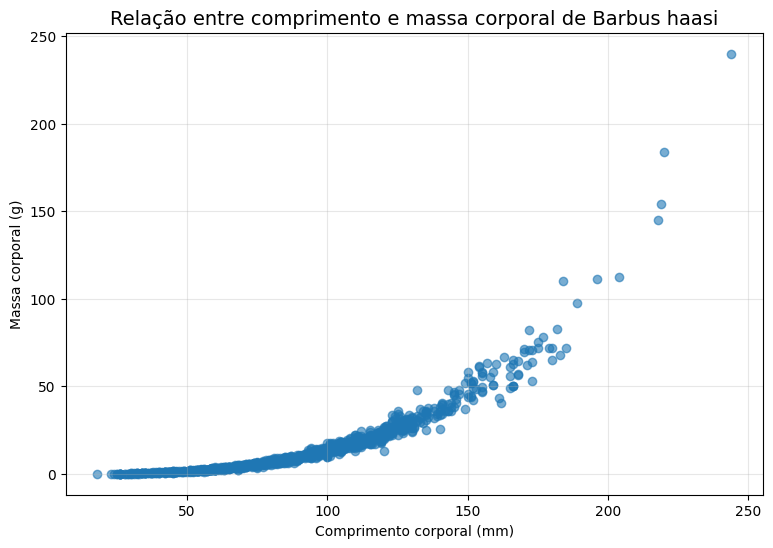

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, alpha=0.6)
plt.title(
    "Relação entre comprimento e massa corporal de Barbus haasi",
    fontsize=14)
plt.xlabel("Comprimento corporal (mm)")
plt.ylabel("Massa corporal (g)")
plt.grid(alpha=0.3)
plt.show()

#3. Regressão linear simples

##A regressão linear simples é uma técnica estatística utilizada para descrever a relação entre duas variáveis numéricas por meio de uma reta.

##O comprimento corporal dos peixes é considerada explicativa ou independente (X), enquanto a massa corporal é considerada resposta ou dependente (Y).
#A equação geral da regressão linear simples é:

$$
\hat{Y} = \beta_0 + \beta_1X
$$


$\hat{Y}$ = valor estimado da variável resposta;
$X$ = valor da variável explicativa;
$\beta_0$ = intercepto da reta;
$\beta_1$ = coeficiente angular da reta.

Os coeficientes são estimados pelas  fórmulas:

$$
\hat{\beta}1 =
\frac{\sum{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sum_{i=1}^{n}(x_i-\bar{x})^2}
$$

e

$$
\hat{\beta}_0 =
\bar{y}-\hat{\beta}_1\bar{x}
$$

In [11]:
x = X.to_numpy()
y = Y.to_numpy()

x_media = np.mean(x)
y_media = np.mean(y)

beta_1 = (
    np.sum((x - x_media) * (y - y_media))
    /
    np.sum((x - x_media) ** 2)
)

beta_0 = y_media - beta_1 * x_media

print(f"Intercepto (β0): {beta_0:.6f}")
print(f"Coeficiente angular (β1): {beta_1:.6f}")

Intercepto (β0): -28.593835
Coeficiente angular (β1): 0.474779


In [12]:
print("Equação da reta de regressão:")
print(f"Massa = {beta_0:.4f} + ({beta_1:.4f} × Comprimento)")

Equação da reta de regressão:
Massa = -28.5938 + (0.4748 × Comprimento)


#4. Interpretação dos coeficientes
##O intercepto $\beta_0$  indica a massa estimada para um peixe com comprimento zero. Como isso não existe na biologia, ele não tem sentido prático real. O valor serve apenas como um ajuste matemático essencial para formar a reta do modelo estatístico.

##O coeficiente angular ($\beta_1$) representa a variação média estimada na massa corporal para cada aumento de 1 mm no comprimento corporal.

##Como o coeficiente angular é positivo, o modelo indica uma tendência de aumento da massa corporal à medida que aumenta o comprimento dos *Barbus haasi*.


# 5. Reta de regressão

##A partir dos coeficientes estimados, é possível calcular a massa corporal prevista pelo modelo para cada valor de comprimento corporal e representar a reta de regressão com os dados observados.


In [ ]:

Y_pred = beta_0 + beta_1 * X
df["Massa_estimada"] = Y_pred
display(df.head())

,Length_mm,Mass_g,Massa_estimada
523,165,60.8,49.744625
528,162,40.7,48.320290
534,105,16.0,21.257913
535,105,14.6,21.257913
536,78,5.4,8.438892


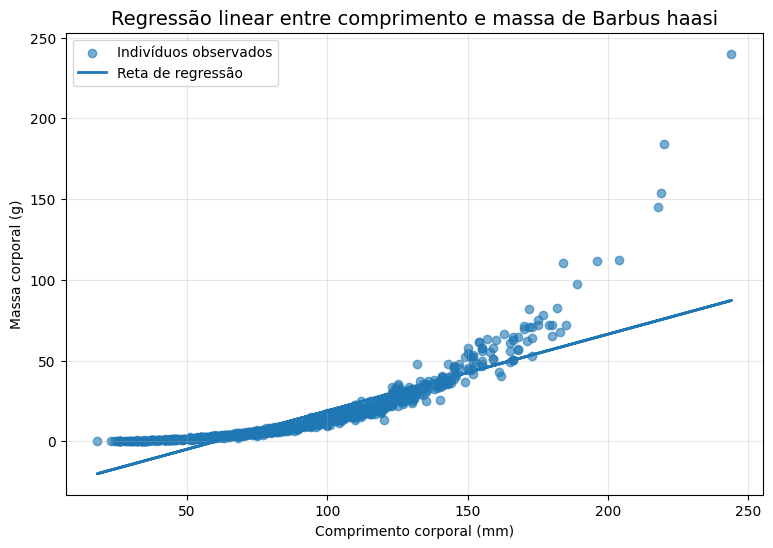

In [16]:


plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    Y,
    alpha=0.6,
    label="Indivíduos observados"
)
Y_pred = beta_0 + beta_1 * X
plt.plot(
    X,
    Y_pred,
    linewidth=2,
    label="Reta de regressão"
)

plt.title(
    "Regressão linear entre comprimento e massa de Barbus haasi",
    fontsize=14
)

plt.xlabel("Comprimento corporal (mm)")
plt.ylabel("Massa corporal (g)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#6. Correlação linear de Pearson

##O coeficiente de correlação linear de Pearson ($r$) é uma medida estatística utilizada para avaliar a direção e a intensidade da associação linear entre duas variáveis numéricas.

##O coeficiente varia entre -1 e +1.

* Valores próximos de +1 indicam uma forte correlação linear positiva;
* Valores próximos de -1 indicam uma forte correlação linear negativa;
* Valores próximos de 0 indicam pouca ou nenhuma associação linear.

##A fórmula do coeficiente de Pearson é:

$$
r =
\frac{
\sum (x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{
\sum(x_i-\bar{x})^2
\sum(y_i-\bar{y})^2
}
}
$$

##O sinal do coeficiente indica a direção da associação, e o valor absoluto indica a intensidade da relação linear.


In [18]:
r, p_valor = pearsonr(X, Y)

print(f"Coeficiente de Pearson (r): {r:.3f}")
print(f"Valor-p: {p_valor:.6e}")

Coeficiente de Pearson (r): 0.864
Valor-p: 0.000000e+00


#7. Direção e intensidade da correlação

##O sinal do coeficiente de Pearson indica a direção da associação entre as variáveis, e o valor absoluto do coeficiente permite avaliar a intensidade da relação linear.
##Uma correlação positiva indica que valores maiores de uma variável costumam estar associados a valores maiores da outra variável. Uma correlação negativa indica que valores maiores de uma variável tendem a estar associados a valores menores da outra.

In [19]:

if r > 0:
    direcao = "positiva"
elif r < 0:
    direcao = "negativa"
else:
    direcao = "próxima de zero"
if abs(r) >= 0.90:
    intensidade = "muito forte"
elif abs(r) >= 0.70:
    intensidade = "forte"
elif abs(r) >= 0.50:
    intensidade = "moderada"
elif abs(r) >= 0.30:
    intensidade = "fraca"
else:
    intensidade = "muito fraca"
print(f"A direção da correlação é {direcao}.")
print(f"A intensidade da correlação é {intensidade}.")

A direção da correlação é positiva.
A intensidade da correlação é forte.


In [ ]:
print(
    f"O coeficiente de correlação de Pearson foi r = {r:.3f}, "
    f"indicando uma correlação linear {intensidade} e {direcao} "
    f"entre o comprimento corporal e a massa dos indivíduos de Barbus haasi."
)

if p_valor < 0.05:
    print(
        f"O valor-p foi {p_valor:.4e}, inferior a 0,05, "
        "indicando evidência estatística de associação linear entre as variáveis."
    )
else:
    print(
        f"O valor-p foi {p_valor:.4e}, superior ou igual a 0,05, "
        "não fornecendo evidência estatística suficiente de associação linear."
    )

O coeficiente de correlação de Pearson foi r = 0.864, indicando uma correlação linear forte e positiva entre o comprimento corporal e a massa dos indivíduos de Barbus haasi.
O valor-p foi 0.0000e+00, inferior a 0,05, indicando evidência estatística de associação linear entre as variáveis.


#9.Limitação da correlação linear

##É importante destacar que o coeficiente de correlação de Pearson avalia especificamente uma relação linear entre duas variáveis.

##Portanto, uma correlação igual ou próxima de zero não significa uma ausência de relação entre as variáveis. Pode existir uma associação não linear, como uma relação curva, não dentificada pelo coeficiente de Pearson.

##Uma correlação elevada não deve ser interpretada automaticamente como uma relação de causa e efeito. A correlação indica associação entre as variáveis, mas é possível estabelecer causalidade.


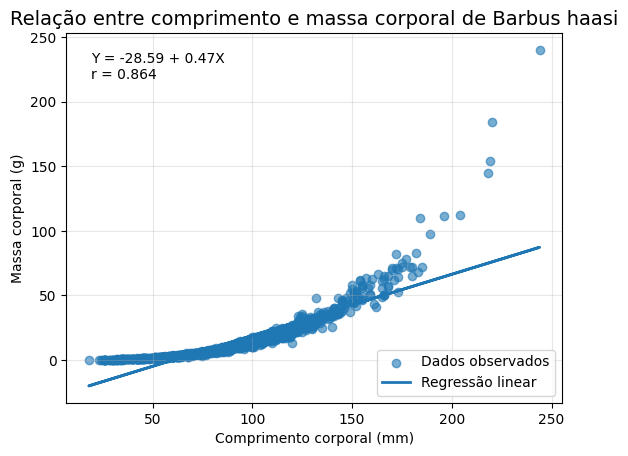

In [22]:


plt.scatter(
    X,
    Y,
    alpha=0.6,
    label="Dados observados"
)

plt.plot(
    X,
    Y_pred,
    linewidth=2,
    label="Regressão linear"
)


texto = (
    f"Y = {beta_0:.2f} + {beta_1:.2f}X\n"
    f"r = {r:.3f}"
)

plt.text(
    0.05,
    0.95,
    texto,
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.title(
    "Relação entre comprimento e massa corporal de Barbus haasi",
    fontsize=14
)

plt.xlabel("Comprimento corporal (mm)")
plt.ylabel("Massa corporal (g)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 10. Conclusão

A análise realizada permitiu investigar a relação entre o comprimento corporal e a massa corporal de indivíduos de *Barbus haasi* utilizando dados reais de peixes de riachos da Península Ibérica.

A regressão linear simples permitiu estimar uma reta capaz de representar a tendência geral dos dados, enquanto o coeficiente de correlação de Pearson permitiu avaliar a direção e a intensidade da associação linear entre as duas variáveis.

Os resultados obtidos indicaram uma associação positiva entre comprimento e massa corporal, demonstrando que indivíduos maiores tendem a apresentar maior massa corporal. O coeficiente de correlação de Pearson permitiu quantificar essa associação, enquanto os coeficientes da regressão permitiram representar matematicamente a relação observada.

No contexto das Ciências Biológicas, essas ferramentas são importantes porque possibilitam identificar e quantificar padrões presentes em dados de organismos, contribuindo para a compreensão de relações entre características morfológicas e outras variáveis biológicas ou ambientais.

Entretanto, é importante considerar que correlação não implica causalidade e que o coeficiente de Pearson avalia especificamente relações lineares. Assim, a interpretação dos resultados deve sempre considerar o contexto biológico e as características dos dados analisados.


## Referências
Autores: Ignasi Arranz, Sandra Brucet, Mireia Bartrons, Carmen García-Comas, Carles Alcaraz, Mònica Bardina, Patricia Navarro Barquero, Frederic Casals, Nuno Caiola, María Concepción Duran, Emili García-Berthou, Alberto Maceda-Veiga, Antoni Munné, María José Rodríguez-Pérez, Carolina Solà, Adolfo de Sostoa e Lluís Benejam.

Título: Individual body mass and length dataset for over 12,000 fish from Iberian streams.

Periódico: Data in Brief, 42, 108248, 2022.

DOI: 10.1016/j.dib.2022.108248.

Repositório: Zenodo:10.5281/zenodo.6327188.

Data de acesso: 23 de agosto de 2026.

ARRANZ, I. et al. Individual body mass and length dataset for over 12,000 fish from Iberian streams. *Data in Brief*, v. 42, 108248, 2022. DOI: 10.1016/j.dib.2022.108248.

